In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
sample = pd.read_csv('SampleSubmission.csv')

In [2]:
train.isnull().sum()

,0
Place_ID X Date,0
Date,0
Place_ID,0
target,0
target_min,0
...,...
L3_CH4_aerosol_optical_depth,24765
L3_CH4_sensor_azimuth_angle,24765
L3_CH4_sensor_zenith_angle,24765
L3_CH4_solar_azimuth_angle,24765


In [3]:
train.dtypes.tolist()

[dtype('O'),
 dtype('O'),
 dtype('O'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('int64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float64'),
 dtype('float

In [4]:
train.dtypes == object

,0
Place_ID X Date,True
Date,True
Place_ID,True
target,False
target_min,False
...,...
L3_CH4_aerosol_optical_depth,False
L3_CH4_sensor_azimuth_angle,False
L3_CH4_sensor_zenith_angle,False
L3_CH4_solar_azimuth_angle,False


In [5]:
train.info()
train.describe()
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30557 entries, 0 to 30556
Data columns (total 82 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Place_ID X Date                                      30557 non-null  object 
 1   Date                                                 30557 non-null  object 
 2   Place_ID                                             30557 non-null  object 
 3   target                                               30557 non-null  float64
 4   target_min                                           30557 non-null  float64
 5   target_max                                           30557 non-null  float64
 6   target_variance                                      30557 non-null  float64
 7   target_count                                         30557 non-null  int64  
 8   precipitable_water_entire_atmosphere                 30557 non-nul

,Place_ID X Date,Date,Place_ID,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,2020-01-02,010Q650,38.0,23.0,53.0,769.50,92,11.000000,60.200001,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,2020-01-03,010Q650,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,2020-01-04,010Q650,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,2020-01-05,010Q650,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,2020-01-06,010Q650,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#Check if placeID, Date and PlaceID have the same values
is_derived = (train['Place_ID'] + ' X ' + train['Date'].astype(str) == train['Place_ID X Date']).all()
test_derived = (test['Place_ID'] + ' X ' + test['Date'].astype(str) == test['Place_ID X Date']).all()
print(f"Is 'Place_ID X Date' a perfect match? {is_derived}")
print(f"Is 'Place_ID X Date' a perfect match? {test_derived}")

Is 'Place_ID X Date' a perfect match? True
Is 'Place_ID X Date' a perfect match? True


In [7]:
#drop the individula date and placeID cols
train_copy = train.copy()
test_copy = test.copy()
train_copy.drop(['Place_ID', 'Date'], axis=1, inplace=True)
test_copy.drop(['Place_ID', 'Date'], axis=1, inplace=True)
train_copy.head()

,Place_ID X Date,target,target_min,target_max,target_variance,target_count,precipitable_water_entire_atmosphere,relative_humidity_2m_above_ground,specific_humidity_2m_above_ground,temperature_2m_above_ground,...,L3_SO2_sensor_zenith_angle,L3_SO2_solar_azimuth_angle,L3_SO2_solar_zenith_angle,L3_CH4_CH4_column_volume_mixing_ratio_dry_air,L3_CH4_aerosol_height,L3_CH4_aerosol_optical_depth,L3_CH4_sensor_azimuth_angle,L3_CH4_sensor_zenith_angle,L3_CH4_solar_azimuth_angle,L3_CH4_solar_zenith_angle
0,010Q650 X 2020-01-02,38.0,23.0,53.0,769.50,92,11.000000,60.200001,0.00804,18.516840,...,38.593017,-61.752587,22.363665,1793.793579,3227.855469,0.010579,74.481049,37.501499,-62.142639,22.545118
1,010Q650 X 2020-01-03,39.0,25.0,63.0,1319.85,91,14.600000,48.799999,0.00839,22.546533,...,59.624912,-67.693509,28.614804,1789.960449,3384.226562,0.015104,75.630043,55.657486,-53.868134,19.293652
2,010Q650 X 2020-01-04,24.0,8.0,56.0,1181.96,96,16.400000,33.400002,0.00750,27.031030,...,49.839714,-78.342701,34.296977,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,010Q650 X 2020-01-05,49.0,10.0,55.0,1113.67,96,6.911948,21.300001,0.00391,23.971857,...,29.181258,-73.896588,30.545446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,010Q650 X 2020-01-06,21.0,9.0,52.0,1164.82,95,13.900001,44.700001,0.00535,16.816309,...,0.797294,-68.612480,26.899694,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
train_copy.isnull().sum()

,0
Place_ID X Date,0
target,0
target_min,0
target_max,0
target_variance,0
...,...
L3_CH4_aerosol_optical_depth,24765
L3_CH4_sensor_azimuth_angle,24765
L3_CH4_sensor_zenith_angle,24765
L3_CH4_solar_azimuth_angle,24765


In [9]:
COlS = [
    'L3_CH4_aerosol_optical_depth',
'L3_CH4_sensor_azimuth_angle',
'L3_CH4_sensor_zenith_angle',
'L3_CH4_solar_azimuth_angle',
'L3_CH4_solar_zenith_angle'
]

for cols in COlS:
    train_copy[cols] = train_copy[cols].fillna(train_copy[cols].median())
    test_copy[cols] = test_copy[cols].fillna(test_copy[cols].median())

# Fill all remaining numeric NaN values with the median of their respective columns
for col in train_copy.select_dtypes(include=np.number).columns:
    if train_copy[col].isnull().any():
        train_copy[col] = train_copy[col].fillna(train_copy[col].median())

for col in test_copy.select_dtypes(include=np.number).columns:
    if test_copy[col].isnull().any():
        test_copy[col] = test_copy[col].fillna(test_copy[col].median())

from sklearn.preprocessing import StandardScaler
target_cols = [col for col in train_copy.columns if 'target' in col]

# Define the common base features (all numeric columns except target-related and 'Place_ID X Date')
common_base_features = [col for col in train_copy.columns if col not in target_cols + ['Place_ID X Date']]

# Features for the first model (model, 74 features)
features_for_model1 = [col for col in common_base_features]

# Prepare X and y for the first model
y = train_copy['target']
X = train_copy[features_for_model1]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Prepare X_test for the first model
X_test = test_copy[features_for_model1]
X_test_scaled = scaler.transform(X_test)

In [10]:
#train model
from sklearn.model_selection import train_test_split
X_train, X_valid, y_train, y_valid = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [11]:
#define the model
from tensorflow.keras import models, layers

model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,913 (27.00 KB)

 Trainable params: 6,913 (27.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
#train
history = model.fit(X_train,y_train, epochs=100, batch_size=32, validation_data=(X_valid, y_valid),verbose=1)

Epoch 1/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2019.9783 - mae: 31.6587 - val_loss: 1409.9604 - val_mae: 26.5787
Epoch 2/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1414.4485 - mae: 26.8949 - val_loss: 1335.2435 - val_mae: 25.4977
Epoch 3/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1395.7245 - mae: 26.7084 - val_loss: 1313.3030 - val_mae: 25.2177
Epoch 4/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1349.0399 - mae: 26.3124 - val_loss: 1285.6689 - val_mae: 25.1060
Epoch 5/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1332.4401 - mae: 26.0632 - val_loss: 1286.0564 - val_mae: 24.8168
Epoch 6/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1323.3099 - mae: 25.9276 - val_loss: 1275.4568 - val_mae: 25.3474
Epoch 7/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1312.1631 - mae: 25.8872 - val_loss: 1264.9869 - val_mae: 24.9695
Epoch 8/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1299.0826 - mae: 25.7809 - val_loss: 1254.4109 - v

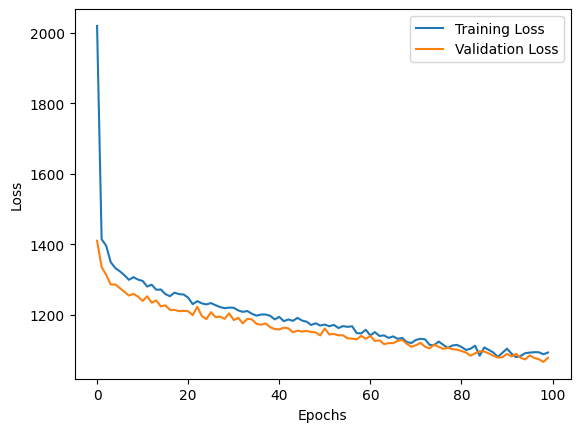

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [14]:
from sklearn.metrics import mean_squared_error
y_pred = model.predict(X_valid)
mse = mean_squared_error(y_valid, y_pred)
val_rsme = np.sqrt(mean_squared_error(y_valid, y_pred))
print(f"Validation RMSE: {val_rsme}")

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Validation RMSE: 32.827469348593006


TRIAL 2


In [15]:
#define cols
COlS = [
    'L3_CH4_aerosol_optical_depth',
'L3_CH4_sensor_azimuth_angle',
'L3_CH4_sensor_zenith_angle',
'L3_CH4_solar_azimuth_angle',
'L3_CH4_solar_zenith_angle'
]
target_cols = [col for col in train_copy.columns if 'target' in col]

# Define the common base features (all numeric columns except target-related and 'Place_ID X Date')
common_base_features = [col for col in train_copy.columns if col not in target_cols + ['Place_ID X Date']]

# Features for the second model (model_dropped, 69 features) - excludes COlS
features_for_model2 = [col for col in common_base_features if col not in COlS]

# Define new X for model_dropped training
X_dropped = train_copy[features_for_model2]

scaled = StandardScaler()
X_dropped_scaled = scaled.fit_transform(X_dropped)

#split data
X_train, X_valid, y_train, y_valid = train_test_split(X_dropped_scaled, y, test_size=0.2,random_state=42)

print(f"Shape of X_train for model_dropped: {X_train.shape}")
print(f"Shape of X_valid for model_dropped: {X_valid.shape}")

Shape of X_train for model_dropped: (24445, 69)
Shape of X_valid for model_dropped: (6112, 69)


In [27]:
#build the model
model_dropped = models.Sequential([
    layers.Dense(64, activation='relu',input_shape=(X_train.shape[1],)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1)
])
model_dropped.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_dropped.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 64)             │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,753 (42.00 KB)

 Trainable params: 10,753 (42.00 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
#fit the model
model_dropped.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_valid, y_valid), verbose=1)

Epoch 1/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 1869.7531 - mae: 30.4019 - val_loss: 1386.1466 - val_mae: 26.1383
Epoch 2/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 1446.3448 - mae: 27.1287 - val_loss: 1328.5928 - val_mae: 25.3374
Epoch 3/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1418.7629 - mae: 26.7263 - val_loss: 1299.3014 - val_mae: 25.4332
Epoch 4/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1377.3068 - mae: 26.3994 - val_loss: 1270.6052 - val_mae: 24.7607
Epoch 5/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1353.0963 - mae: 26.1367 - val_loss: 1244.2422 - val_mae: 24.5661
Epoch 6/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 1335.1617 - mae: 25.9108 - val_loss: 1260.4200 - val_mae: 24.4605
Epoch 7/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1336.9336 - mae: 25.9083 - val_loss: 1278.8368 - val_mae: 24.1568
Epoch 8/100
764/764 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 1320.4226 - mae: 25.7168 - val_loss: 1230.8402 - v

In [30]:
#RMSE
y_pred_dropped = model_dropped.predict(X_valid)
mse_dropped = mean_squared_error(y_valid, y_pred_dropped)
print(f"Validation RMSE: {np.sqrt(mse_dropped)}")

191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Validation RMSE: 31.67091744946606


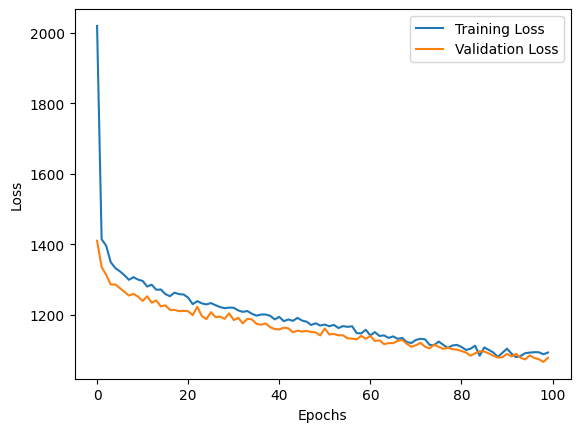

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [32]:
#test
test_copy.head()

# Define the common base features (all numeric columns except target-related and 'Place_ID X Date')
common_base_features = [col for col in train_copy.columns if col not in target_cols + ['Place_ID X Date']]

# Features for the second model (model_dropped, 69 features) - excludes COlS
features_for_model2 = [col for col in common_base_features if col not in COlS]

# Prepare X_test_final using the same feature set as X_dropped
X_test_final = test_copy[features_for_model2]

In [33]:
X_test_final_scaled = scaled.transform(X_test_final)

In [31]:
#predictions
y_pred_test = model_dropped.predict(X_test_final_scaled)

505/505 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [34]:
submission = sample.copy()
submission['target'] = y_pred_test
submission.to_csv('my submission.csv', index=False)

print("Final submission file created successfully!")

Final submission file created successfully!


In [37]:
# Load both files
sample = pd.read_csv("SampleSubmission.csv")
my_sub = pd.read_csv("my submission.csv")

# Check if columns match exactly
if list(sample.columns) == list(my_sub.columns):
    print("✅ Columns match perfectly!")
else:
    print("❌ Columns do NOT match!")
    print(f"Expected: {list(sample.columns)}")
    print(f"Yours:    {list(my_sub.columns)}")

✅ Columns match perfectly!
